In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('insurance.csv')

In [5]:
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


In [6]:
df.shape

(986, 11)

In [7]:
  # Upgrade to the latest version of mlxtend
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [8]:
# Adjusted R2 custom scorer
def adjusted_r2_score(estimator, X, y):
    """
    Calculate adjusted R-squared for cross-validation.
    """
    n, p = X.shape  # Number of samples (n) and predictors (p)
    y_pred = estimator.predict(X)
    r2 = 1 - (np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2))
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    return adj_r2

def r_squared(y_true, y_pred):
  """
  Calculates the R-squared value.

  Args:
    y_true: The actual values.
    y_pred: The predicted values.

  Returns:
    The R-squared value.
  """
  ss_res = np.sum((y_true - y_pred)**2)
  ss_tot = np.sum((y_true - np.mean(y_true))**2)
  r2 = 1 - (ss_res / ss_tot)
  return r2

In [9]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Assuming your DataFrame is named 'df'
X = df.drop('PremiumPrice', axis=1)
y = df['PremiumPrice']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=86, random_state=42)

In [10]:
# importing the models
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np
import pandas as pd

## We will use mlxtent for forward and backward selection

In [11]:
# calling the linear regression model
from sklearn.metrics import make_scorer, mean_squared_error
lreg = LinearRegression()
# Define the Sequential Feature Selector
# Define the Sequential Feature Selector
# Define the model
lreg = LinearRegression()

# Define the Sequential Feature Selector
sfs1 = SFS(
    estimator=lreg,
    k_features=5,  # Number of features to select
    forward=True,
    floating=False,
    scoring=make_scorer(r_squared, greater_is_better=True),  # Use adjusted R2
    cv=5,  # Cross-validation folds
    n_jobs=-1  # Use all processors
)

In [12]:
# Fit the selector
sfs1 = sfs1.fit(X_train, y_train)

# Get selected features
selected_features = sfs1.k_feature_names_
print("Selected features:", selected_features)

# Transform the dataset with selected features
X_train_sfs = sfs1.transform(X_train)
X_test_sfs = sfs1.transform(X_test)

# Train a new model on selected features
lreg.fit(X_train_sfs, y_train)
y_pred = lreg.predict(X_test_sfs)

Selected features: ('Age', 'AnyTransplants', 'AnyChronicDiseases', 'Weight', 'HistoryOfCancerInFamily')


## We have used forward selection with R-Squared Let us check how Actual is different from Predicted

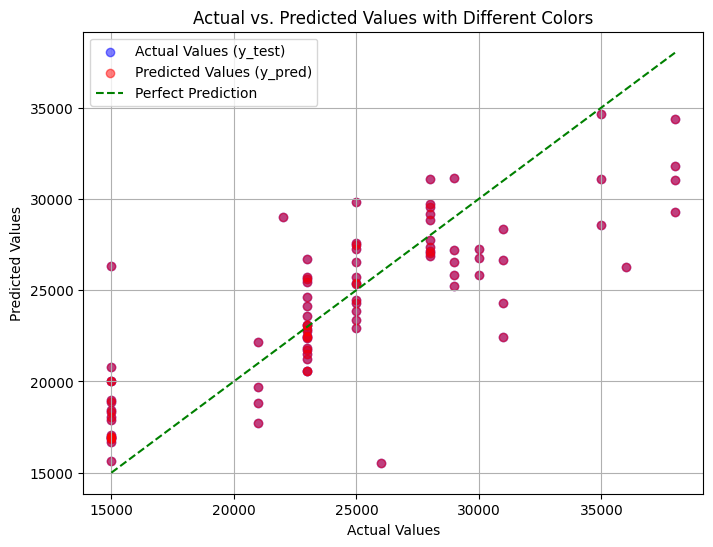

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have y_test and y_pred

# Create a scatter plot for y_test (Actual Values)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', label='Actual Values (y_test)', alpha=0.5)


# Create a scatter plot for y_pred (Predicted Values) with a different color
plt.scatter(y_test, y_pred, color='red', label='Predicted Values (y_pred)', alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values with Different Colors")

# Add a diagonal line for reference
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='green', linestyle='--', label='Perfect Prediction')

# Add a legend
plt.legend()

plt.grid(True)
plt.show()

## We will use random forest for regression to see if we check how well it performs in test

In [14]:
#We will use random forest for X_train and y_train
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


In [15]:
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)  # You can adjust hyperparameters
rf_regressor.fit(X_train, y_train)
y_pred = rf_regressor.predict(X_test)

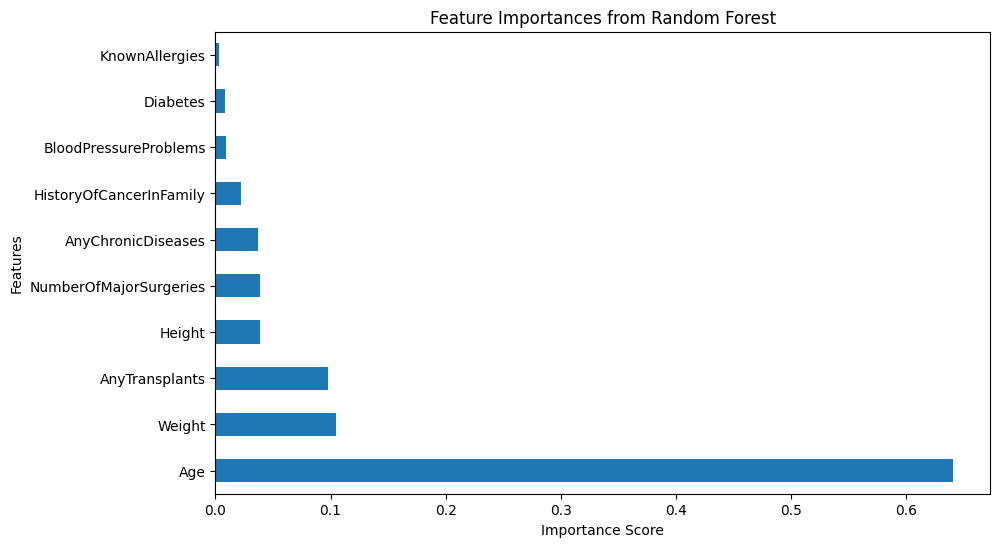

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances
importances = rf_regressor.feature_importances_

# Create a pandas Series for easier plotting
feature_importances = pd.Series(importances, index=X_train.columns)

# Sort feature importances in descending order
feature_importances = feature_importances.sort_values(ascending=False)

# Create a horizontal bar plot
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='barh')
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

## We could see Age is greatly influencing the PremiumPrice and naturally so

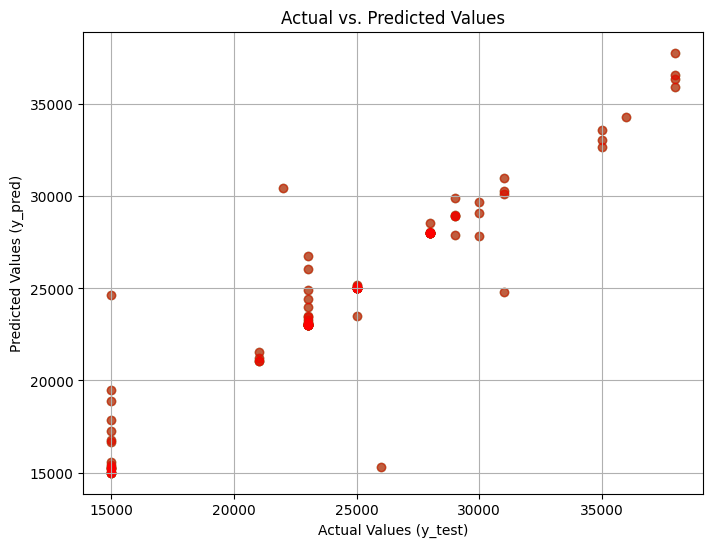

In [17]:
# We will use y_pred and plot y_test and plot the scatterplot
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
plt.scatter(y_test, y_pred, color='green', label='Actual Values (y_test)', alpha=0.5)


# Create a scatter plot for y_pred (Predicted Values) with a different color
plt.scatter(y_test, y_pred, color='red', label='Predicted Values (y_pred)', alpha=0.5)
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Actual vs. Predicted Values")
plt.grid(True)  # Add a grid for better visualization
plt.show()

In [18]:
# We will use r2 to check if y_pred and y_test
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R2) Score: {r2}")

R-squared (R2) Score: 0.8677727529075069


## This is great we are able to at least explain 86 % of the outcome

R-squared (R2) Score with selected features: 0.9033017585331294


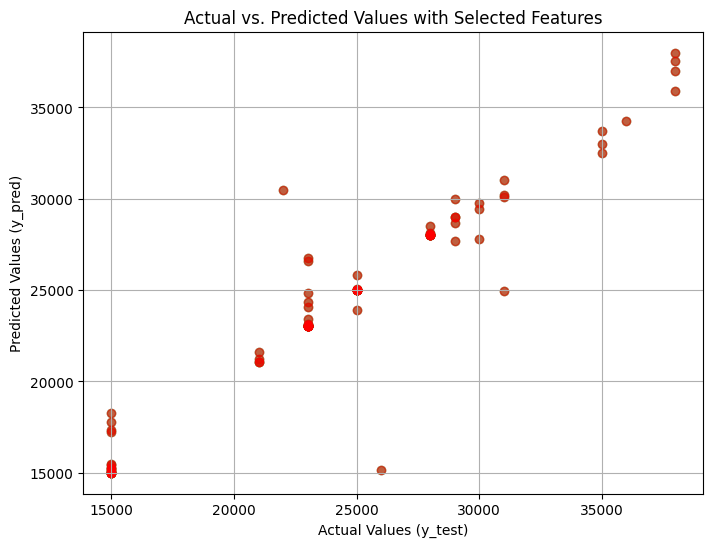

In [20]:
#Let us just use the feature importance features for training and validation
# Get feature importances from the Random Forest model
importances = rf_regressor.feature_importances_

# Create a pandas Series for easier handling
feature_importances = pd.Series(importances, index=X_train.columns)

# Select the top 5 most important features
top_7_features = feature_importances.nlargest(7).index

# Filter the training and testing sets to include only the selected features
X_train_selected = X_train[top_7_features]
X_test_selected = X_test[top_7_features]

# Train a new Random Forest model with the selected features
rf_regressor_selected = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor_selected.fit(X_train_selected, y_train)

# Make predictions on the test set
y_pred_selected = rf_regressor_selected.predict(X_test_selected)

# Evaluate the model
r2_selected = r2_score(y_test, y_pred_selected)
print(f"R-squared (R2) Score with selected features: {r2_selected}")

# Plotting actual vs predicted values for the selected feature model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_selected, color='green', label='Actual Values (y_test)', alpha=0.5)
plt.scatter(y_test, y_pred_selected, color='red', label='Predicted Values (y_pred)', alpha=0.5)
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Actual vs. Predicted Values with Selected Features")
plt.grid(True)
plt.show()

## We could see that top 7 features are giving us the best results

In [21]:
#Please save the rf_regressor_selected model file
import joblib
joblib.dump(rf_regressor_selected, 'rf_regressor_selected.pkl')

['rf_regressor_selected.pkl']

In [22]:
#LEt us plot the column info and data type of the top_7_features
for column in top_7_features:
    print(f"Column: {column}")
    print(f"Data Type: {df[column].dtype}")
    print()

Column: Age
Data Type: int64

Column: Weight
Data Type: int64

Column: AnyTransplants
Data Type: int64

Column: Height
Data Type: int64

Column: NumberOfMajorSurgeries
Data Type: int64

Column: AnyChronicDiseases
Data Type: int64

Column: HistoryOfCancerInFamily
Data Type: int64

